# **FASE 1: ENFOQUE HOLÍSTICO Y EL LÍMITE ARQUITECTÓNICO (VGG16)**

Autor: Andoni Cabrera Fernández

Descripción: Este cuaderno documenta la evolución iterativa sobre la VGG16. Demuestra empíricamente el "Sesgo de Identidad": cómo la red memoriza rostros (Overfitting) y cómo, a pesar de aplicar GAP, regularización L2 y un Information Bottleneck extremo, el modelo colapsa al 40% en validación.



**1. IMPORTACIÓN Y CONFIGURACIÓN**


In [1]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Descompresión
ruta_zip = '/content/drive/MyDrive/TFG_Fatiga_Colab/Caras_Recortadas_Procesadas.zip'
ruta_trabajo = '/content/dataset_fatiga'
ruta_dataset = '/content/dataset_fatiga/Caras_Recortadas_Procesadas'

if not os.path.exists(ruta_trabajo):
    print("Descomprimiendo el dataset...")
    !unzip -q "{ruta_zip}" -d "{ruta_trabajo}"
    print("¡Descompresión completada!")
else:
    print("El dataset ya está listo en la memoria temporal.")

# 3. Creación de DataFrames
folds_dict = {f'Fold{i}': [] for i in range(1, 6)}
for carpeta in os.listdir(ruta_dataset):
    for i in range(1, 6):
        if f"Fold{i}" in carpeta:
            folds_dict[f'Fold{i}'].append(os.path.join(ruta_dataset, carpeta))

def crear_dataframe_desde_folds(lista_folds):
    rutas, etiquetas = [], []
    for ruta_fold in lista_folds:
        for raiz, _, archivos in os.walk(ruta_fold):
            clase = os.path.basename(raiz)
            if clase in ['Clase_0', 'Clase_5', 'Clase_10']:
                for archivo in archivos:
                    if archivo.endswith(('.jpg', '.png')):
                        rutas.append(os.path.join(raiz, archivo))
                        etiquetas.append(clase)
    return pd.DataFrame({'ruta': rutas, 'clase': etiquetas})

# PROTOCOLO 3-1-1 FINAL
df_train = crear_dataframe_desde_folds(folds_dict['Fold2'] + folds_dict['Fold3'] + folds_dict['Fold4'])
df_val = crear_dataframe_desde_folds(folds_dict['Fold5'])
df_test = crear_dataframe_desde_folds(folds_dict['Fold1'])

print(f"\nConfiguración finalizada.")
print(f"Train: {len(df_train)} | Val (Fold 5): {len(df_val)} | Test (Fold 1): {len(df_test)}")

Mounted at /content/drive
Descomprimiendo el dataset...
¡Descompresión completada!

Configuración finalizada.
Train: 60883 | Val (Fold 5): 20899 | Test (Fold 1): 20467


**2. GENERADORES Y DATA AUGMENTATION**

In [2]:
# Data Augmentation para entrenamiento
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.6, 1.4],
    horizontal_flip=True,
    fill_mode='nearest'
)

# Sin aumento para Validación y Test
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    df_train, x_col='ruta', y_col='clase', target_size=(224,224),
    batch_size=32, class_mode='categorical', shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    df_val, x_col='ruta', y_col='clase', target_size=(224,224),
    batch_size=32, class_mode='categorical', shuffle=False
)

test_gen = val_datagen.flow_from_dataframe(
    df_test, x_col='ruta', y_col='clase', target_size=(224,224),
    batch_size=32, class_mode='categorical', shuffle=False
)

Found 60883 validated image filenames belonging to 3 classes.
Found 20899 validated image filenames belonging to 3 classes.
Found 20467 validated image filenames belonging to 3 classes.


**3. CONSTRUCCIÓN DE LA ARQUITECTURA (VGG16 OPTIMIZADA)**

In [3]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Descongelación a partir del Bloque 5
base_model.trainable = True
for layer in base_model.layers:
    if layer.name == 'block5_conv1':
        break
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.1)),
    BatchNormalization(),
    Dropout(0.7),
    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
print("\nArquitectura Final (Fase 1 - VGG16):")
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Arquitectura Final (Fase 1 - VGG16):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,747,971 (56.26 MB)

 Trainable params: 7,112,579 (27.13 MB)

 Non-trainable params: 7,635,392 (29.13 MB)

**4. ENTRENAMIENTO CON CALLBACKS Y DEMOSTRACIÓN DEL LÍMITE TÉCNICO**


In [4]:
ruta_keras = '/content/drive/MyDrive/TFG_Fatiga_Colab/vgg16_fase1_definitivo.keras'

callbacks_list = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(ruta_keras, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

print("\nIniciando Entrenamiento VGG16...")
historial = model.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=callbacks_list
)


Iniciando Entrenamiento VGG16...
Epoch 1/50
1903/1903 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.5413 - loss: 11.8941
Epoch 1: val_accuracy improved from None to 0.28547, saving model to /content/drive/MyDrive/TFG_Fatiga_Colab/vgg16_fase1_definitivo.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TFG_Fatiga_Colab/vgg16_fase1_definitivo.keras
1903/1903 ━━━━━━━━━━━━━━━━━━━━ 1259s 652ms/step - accuracy: 0.6797 - loss: 10.6420 - val_accuracy: 0.2855 - val_loss: 10.7094 - learning_rate: 1.0000e-05
Epoch 2/50
1903/1903 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.8999 - loss: 7.7558
Epoch 2: val_accuracy improved from 0.28547 to 0.28652, saving model to /content/drive/MyDrive/TFG_Fatiga_Colab/vgg16_fase1_definitivo.keras

Epoch 2: finished saving model to /content/drive/MyDrive/TFG_Fatiga_Colab/vgg16_fase1_definitivo.keras
1903/1903 ━━━━━━━━━━━━━━━━━━━━ 1207s 634ms/step - accuracy: 0.9219 - loss: 7.0071 - val_accuracy: 0.2865 - val_loss: 8.8314 - learning_rate: 1.0

**6. VISUALIZACIÓN DEL COLAPSO (SESGO DE IDENTIDAD)**

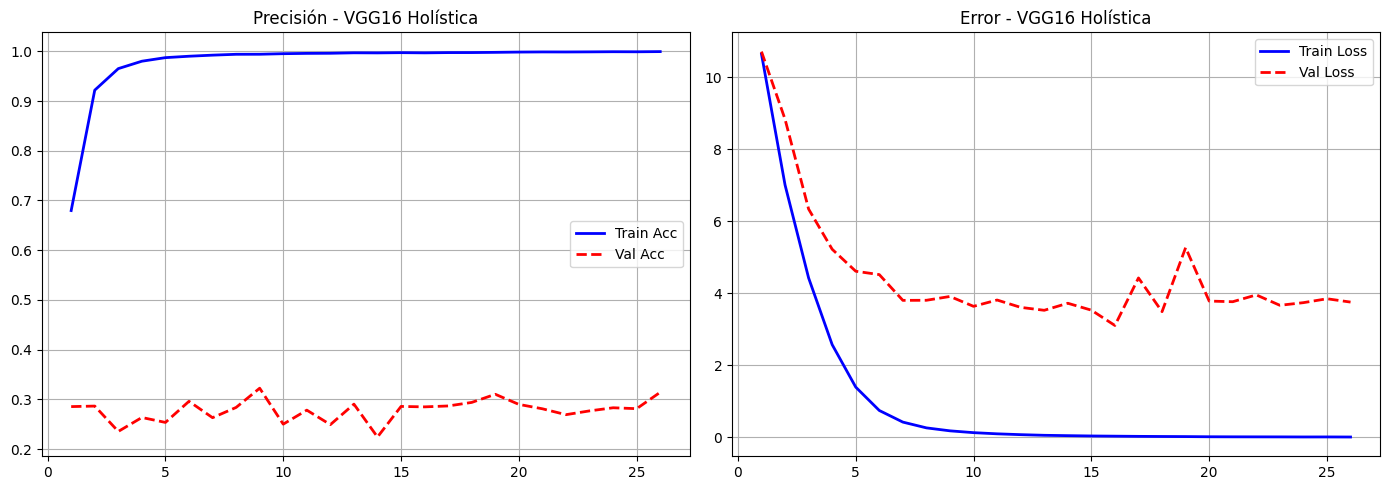

In [5]:
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']
epocas = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epocas, acc, 'b-', label='Train Acc', linewidth=2)
plt.plot(epocas, val_acc, 'r--', label='Val Acc', linewidth=2)
plt.title('Precisión - VGG16 Holística')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epocas, loss, 'b-', label='Train Loss', linewidth=2)
plt.plot(epocas, val_loss, 'r--', label='Val Loss', linewidth=2)
plt.title('Error - VGG16 Holística')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

**7. MATRIZ DE CONFUSIÓN**


--- EVALUACIÓN FINAL SOBRE SUJETOS NO VISTOS (TEST CIEGO - FOLD 1) ---
640/640 ━━━━━━━━━━━━━━━━━━━━ 115s 178ms/step


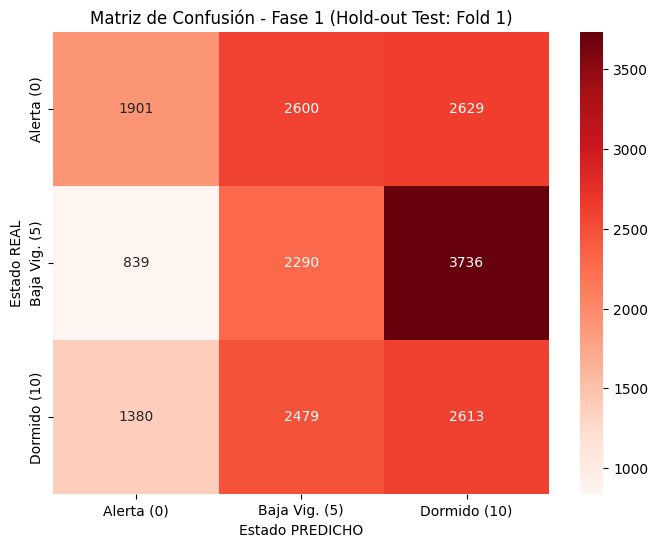


REPORTE DE CLASIFICACIÓN FINAL:
               precision    recall  f1-score   support

   Alerta (0)       0.46      0.27      0.34      7130
Baja Vig. (5)       0.31      0.33      0.32      6865
 Dormido (10)       0.29      0.40      0.34      6472

     accuracy                           0.33     20467
    macro avg       0.35      0.33      0.33     20467
 weighted avg       0.36      0.33      0.33     20467



In [6]:
print("\n--- EVALUACIÓN FINAL SOBRE SUJETOS NO VISTOS (TEST CIEGO - FOLD 1) ---")

test_gen.reset()
predicciones = model.predict(test_gen)
y_pred = np.argmax(predicciones, axis=1)
y_true = test_gen.classes

etiquetas = ['Alerta (0)', 'Baja Vig. (5)', 'Dormido (10)']

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=etiquetas, yticklabels=etiquetas)
plt.title('Matriz de Confusión - Fase 1 (Hold-out Test: Fold 1)')
plt.ylabel('Estado REAL')
plt.xlabel('Estado PREDICHO')
plt.show()

print("\nREPORTE DE CLASIFICACIÓN FINAL:")
print(classification_report(y_true, y_pred, target_names=etiquetas))